In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import time
import pandas as pd
import heapq
from IPython.display import display

/home/fahmialfayadh/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
G = nx.Graph()
num_nodes = 10
G.add_nodes_from(range(num_nodes))

# buat edge random supaya graf terhubung (connected)
# 1, buat spanning tree agar pasti terhubung
nodes = list(range(num_nodes))

random.shuffle(nodes) # shuffle

for i in range(len(nodes) - 1):
    w = random.randint(1, 20)
    G.add_edge(nodes[i], nodes[i+1], weight=w) #tambah bobot random

# add edge random tambahan 
for _ in range(10):
    u = random.randint(0, num_nodes - 1)
    v = random.randint(0, num_nodes - 1)
    if u != v and not G.has_edge(u, v):
        w = random.randint(1, 20)
        G.add_edge(u, v, weight=w)



=== Daftar Ketetanggaan (Adjacency List) ===
Node 0: {'5': 12, '8': 8, '6': 13}
Node 1: {'2': 5, '6': 2}
Node 2: {'8': 7, '1': 5, '6': 7}
Node 3: {'6': 15}
Node 4: {'9': 5, '5': 2}
Node 5: {'7': 17, '0': 12, '6': 17, '4': 2}
Node 6: {'1': 2, '3': 15, '5': 17, '2': 7, '7': 1, '0': 13}
Node 7: {'9': 17, '5': 17, '6': 1}
Node 8: {'0': 8, '2': 7}
Node 9: {'4': 5, '7': 17}

Jumlah node: 10
Jumlah edge: 14
Daftar edge beserta bobot: [(0, 5, 12), (0, 8, 8), (0, 6, 13), (1, 2, 5), (1, 6, 2), (2, 8, 7), (2, 6, 7), (3, 6, 15), (4, 9, 5), (4, 5, 2), (5, 7, 17), (5, 6, 17), (6, 7, 1), (7, 9, 17)]


/tmp/ipykernel_135168/807458179.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


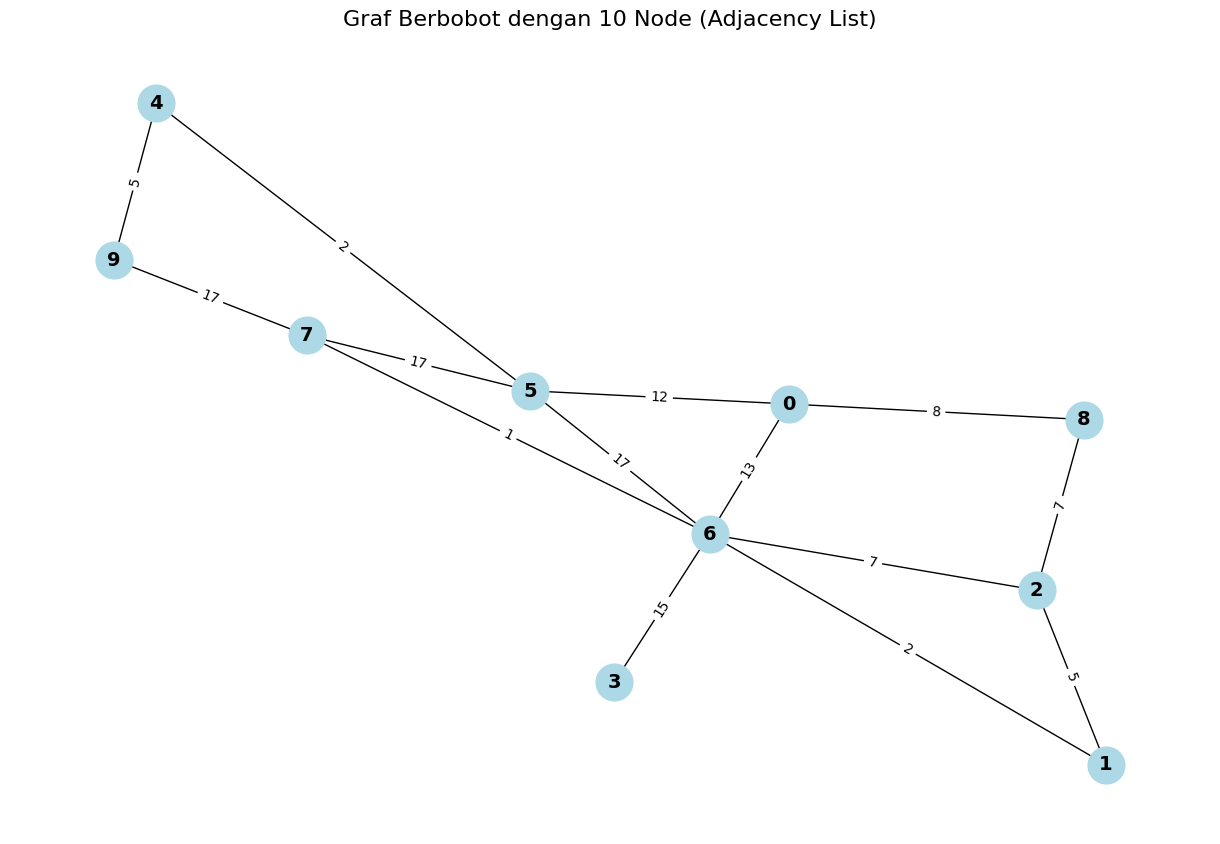

In [5]:
# print adjacency list
print("=== Daftar Ketetanggaan (Adjacency List) ===")
for node in sorted(G.nodes()):
    neighbors = {str(n): G.edges[node, n]["weight"] for n in G.neighbors(node)}
    print(f"Node {node}: {neighbors}")

print(f"\nJumlah node: {G.number_of_nodes()}")
print(f"Jumlah edge: {G.number_of_edges()}")
print(f"Daftar edge beserta bobot: {[(u, v, d['weight']) for u, v, d in G.edges(data=True)]}")

# Visualisasi graf
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=700, font_size=14, font_weight="bold")
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)
plt.title("Graf Berbobot dengan 10 Node (Adjacency List)", fontsize=16)
plt.tight_layout()
plt.show()

# Implementasi Algoritma Minimum Spanning Tree (MST)


### a. Kruskal's Algorithm

In [8]:
# Kruskal's Algorithmeeeeeeeeee
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display

def kruskal(graph):
    edges = []
    for u, v, data in graph.edges(data=True):
        edges.append((data["weight"], u, v))
    edges.sort()  # urutkan edge berdasarkan bobot
    
    nodes = sorted(graph.nodes())
    
    #tambahkan id tiap node agar memastikan tidak ada looop
    comp_id = {node: node for node in nodes}
    
    mst_edges = []
    total_weight = 0
    steps = []  # untuk log langkah buat visualisasi
    
    for weight, u, v in edges:
        # if ID komponen u dan v berbeda, berarti belum terhubung dan tidak akan membentuk siklus
        if comp_id[u] != comp_id[v]:
            mst_edges.append((u, v, weight)) 
            total_weight += weight #tambah weigthyna
            steps.append({"Edge": f"({u}, {v})", "Bobot": weight, "Status": "Diterima", "Total_Bobot_MST": total_weight})
            
            # gabungkan kedua komponen
            # all node yang memiliki komponen ID sama dengan v akan diubah menjadi ID komponen u
            old_id = comp_id[v]
            new_id = comp_id[u]
            for node in comp_id:
                if comp_id[node] == old_id:
                    comp_id[node] = new_id
        else:
            steps.append({"Edge": f"({u}, {v})", "Bobot": weight, "Status": "Ditolak (Siklus)", "Total_Bobot_MST": total_weight})
    
    return mst_edges, total_weight, steps




=== Hasil Kruskal's Algorithm ===
Edge MST: [(6, 7, 1), (1, 6, 2), (4, 5, 2), (1, 2, 5), (4, 9, 5), (2, 8, 7), (0, 8, 8), (0, 5, 12), (3, 6, 15)]
Total bobot MST: 57

Tabel Proses Kruskal:


,Edge,Bobot,Status,Total_Bobot_MST
0,"(6, 7)",1,Diterima,1
1,"(1, 6)",2,Diterima,3
2,"(4, 5)",2,Diterima,5
3,"(1, 2)",5,Diterima,10
4,"(4, 9)",5,Diterima,15
5,"(2, 6)",7,Ditolak (Siklus),15
6,"(2, 8)",7,Diterima,22
7,"(0, 8)",8,Diterima,30
8,"(0, 5)",12,Diterima,42
9,"(0, 6)",13,Ditolak (Siklus),42


/tmp/ipykernel_135168/12927478.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


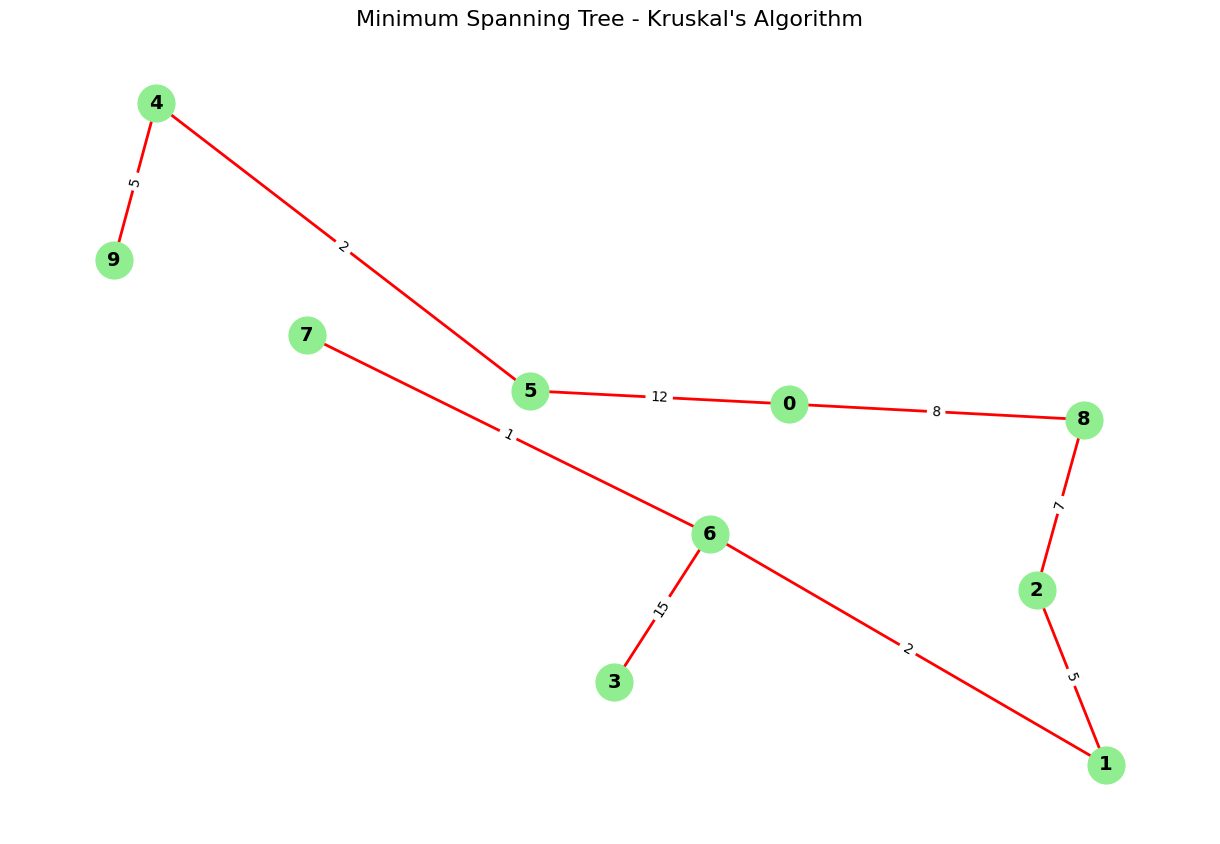

In [10]:
#output dan visualisasi

mst_kruskal, total_kruskal, steps_kruskal = kruskal(G)

print("=== Hasil Kruskal's Algorithm ===")
print(f"Edge MST: {mst_kruskal}")
print(f"Total bobot MST: {total_kruskal}")

# Tabel audit trail
df_kruskal = pd.DataFrame(steps_kruskal)
print("\nTabel Proses Kruskal:")
display(df_kruskal)

# Visualisasi MST Kruskal
MST_K = nx.Graph()
for u, v, w in mst_kruskal:
    MST_K.add_edge(u, v, weight=w)

plt.figure(figsize=(12, 8))
nx.draw(MST_K, pos, with_labels=True, node_color="lightgreen", node_size=700, font_size=14, font_weight="bold", edge_color="red", width=2)
edge_labels_k = nx.get_edge_attributes(MST_K, "weight")
nx.draw_networkx_edge_labels(MST_K, pos, edge_labels=edge_labels_k, font_size=10)
plt.title("Minimum Spanning Tree - Kruskal's Algorithm", fontsize=16)
plt.tight_layout()
plt.show()

# penejlasan Kruskal's Algorithm

Algoritma Kruskal menemukan MST (minimum spanning tree) dengan pendekatan **greedy berbasis edge**. Edge-edge diurutkan berdasarkan bobot, kemudian ditambahkan satu per satu ke MST jika tidak membentuk siklus.

---

## 1. id node

```python
comp_id = {node: node for node in nodes}
```

setiap node memiliki id sendiri berguna untuk ngecek apakah edges nantinya membentuk siklus atau tidak

---

## 2. Pengurutan Edge

```python
for u, v, data in graph.edges(data=True):
    edges.append((data["weight"], u, v))
edges.sort()
```

Semua edge dikumpulkan dan **diurutkan berdasarkan bobot** dari kecil ke besar. Ini adalah langkah kunci dari pendekatan greedy Kruskal.

---

## 3. Proses Seleksi Edge dan Penggabungan Komponen

```python
if comp_id[u] != comp_id[v]:
    mst_edges.append((u, v, weight))
    
    old_id = comp_id[v]
    new_id = comp_id[u]
    for node in comp_id:
        if comp_id[node] == old_id:
            comp_id[node] = new_id
```

Untuk setiap edge (mulai dari bobot terkecil), kita mengecek apakah `u` dan `v` berada di komponen yang berbeda.
- Jika nilainya **berbeda**, itu berarti mereka belum terhubung. Kita tambahkan edge tersebut ke MST dan **gabungkan komponennya** (mengubah semua node yang berkomponen `v` menjadi komponen `u`).
- Jika nilainya **sama**, mereka sudah terhubung melalui edge sebelumnya. Menambahkan edge baru ini hanya akan **membentuk siklus**, sehingga edge ini kita **tolak**.

---


### b. Prim's Algorithm

=== Hasil Prim's Algorithm ===
Edge MST: [(0, 8, 8), (8, 2, 7), (2, 1, 5), (1, 6, 2), (6, 7, 1), (0, 5, 12), (5, 4, 2), (4, 9, 5), (6, 3, 15)]
Total bobot MST: 57

Tabel Proses Prim:


,Edge,Bobot,Status,Total_Bobot_MST
0,"(0, 8)",8,Diterima,8
1,"(8, 2)",7,Diterima,15
2,"(2, 1)",5,Diterima,20
3,"(1, 6)",2,Diterima,22
4,"(6, 7)",1,Diterima,23
5,"(2, 6)",7,Dilewati (sudah dikunjungi),23
6,"(0, 5)",12,Diterima,35
7,"(5, 4)",2,Diterima,37
8,"(4, 9)",5,Diterima,42
9,"(0, 6)",13,Dilewati (sudah dikunjungi),42


/tmp/ipykernel_135168/1651300265.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


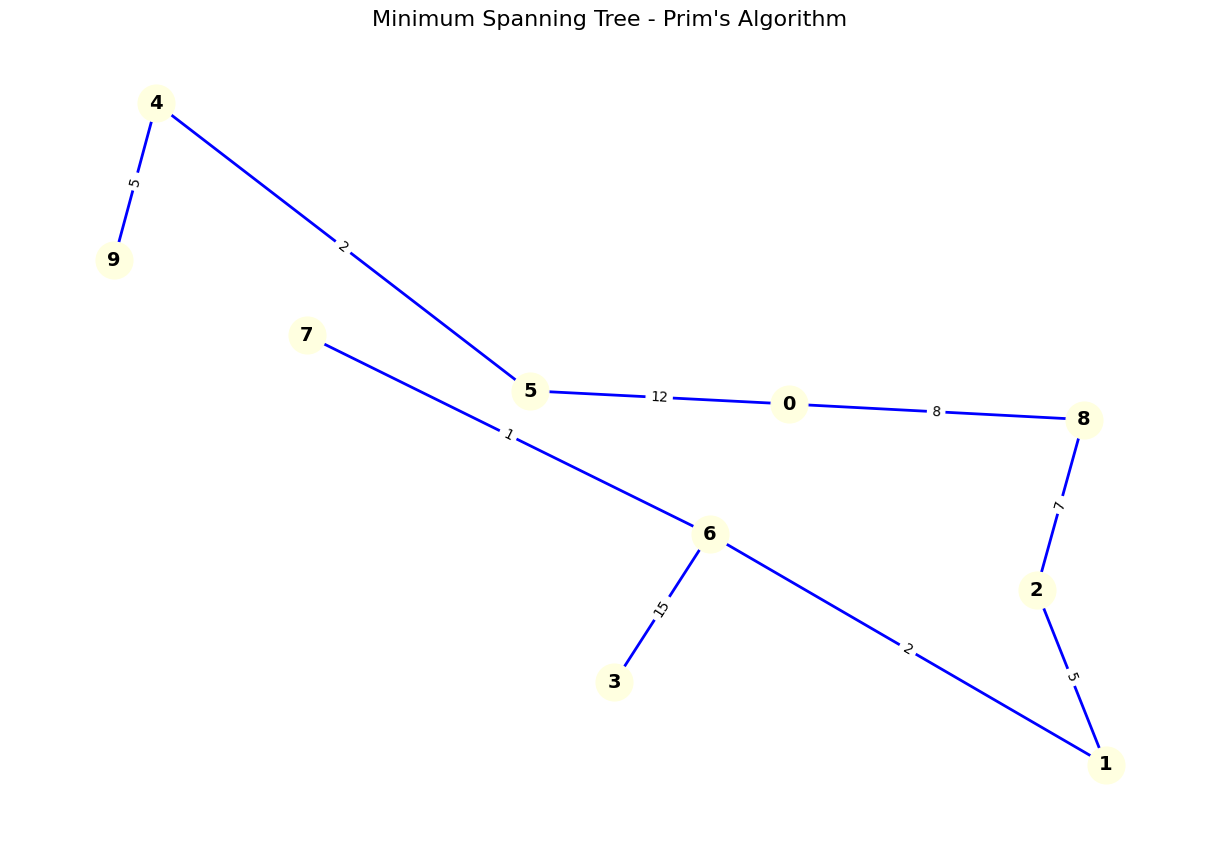

In [7]:
# Implementasi Prim's Algorithm

def prim(graph, start=0):
    visited = set()
    mst_edges = []
    total_weight = 0
    steps = []
    
    # Priority queue: (weight, u, v) 
    min_heap = []
    visited.add(start)
    
    for neighbor in graph.neighbors(start):
        w = graph.edges[start, neighbor]["weight"]
        heapq.heappush(min_heap, (w, start, neighbor))
    
    while min_heap and len(visited) < len(graph.nodes()):
        weight, u, v = heapq.heappop(min_heap)
        
        if v in visited:
            steps.append({"Edge": f"({u}, {v})", "Bobot": weight, "Status": "Dilewati (sudah dikunjungi)", "Total_Bobot_MST": total_weight})
            continue
        
        visited.add(v)
        mst_edges.append((u, v, weight))
        total_weight += weight
        steps.append({"Edge": f"({u}, {v})", "Bobot": weight, "Status": "Diterima", "Total_Bobot_MST": total_weight})
        
        for neighbor in graph.neighbors(v):
            if neighbor not in visited:
                w = graph.edges[v, neighbor]["weight"]
                heapq.heappush(min_heap, (w, v, neighbor))
    
    return mst_edges, total_weight, steps

mst_prim, total_prim, steps_prim = prim(G)

print("=== Hasil Prim's Algorithm ===")
print(f"Edge MST: {mst_prim}")
print(f"Total bobot MST: {total_prim}")

# Tabel audit trail
df_prim = pd.DataFrame(steps_prim)
print("\nTabel Proses Prim:")
display(df_prim)

# Visualisasi MST Prim
MST_P = nx.Graph()
for u, v, w in mst_prim:
    MST_P.add_edge(u, v, weight=w)

plt.figure(figsize=(12, 8))
nx.draw(MST_P, pos, with_labels=True, node_color="lightyellow", node_size=700, font_size=14, font_weight="bold", edge_color="blue", width=2)
edge_labels_p = nx.get_edge_attributes(MST_P, "weight")
nx.draw_networkx_edge_labels(MST_P, pos, edge_labels=edge_labels_p, font_size=10)
plt.title("Minimum Spanning Tree - Prim's Algorithm", fontsize=16)
plt.tight_layout()
plt.show()

# Dokumentasi Prim's Algorithm

Algoritma Prim membangun MST dengan pendekatan **greedy berbasis node**. Dimulai dari satu node, algoritma terus menambahkan edge termurah yang menghubungkan node yang sudah dikunjungi ke node yang belum dikunjungi.

---

## 1. Inisialisasi

```python
visited = set()
min_heap = []
visited.add(start)
```

Menyiapkan set `visited` untuk melacak node yang sudah masuk MST. Node awal langsung ditandai sebagai sudah dikunjungi.

```python
for neighbor in graph.neighbors(start):
    w = graph.edges[start, neighbor]["weight"]
    heapq.heappush(min_heap, (w, start, neighbor))
```

Semua edge yang bertetangga dengan node awal dimasukkan ke **priority queue (min-heap)**.

---

## 2. Proses Pembangunan MST

```python
while min_heap and len(visited) < len(graph.nodes()):
    weight, u, v = heapq.heappop(min_heap)
```

Melakukan perulangan selama masih ada edge dalam antrean dan belum semua node dikunjungi. Mengambil edge dengan bobot minimum.

```python
if v in visited:
    continue
```

Jika node tujuan sudah dikunjungi, lewati edge tersebut untuk menghindari siklus.

---

## 3. Penambahan Edge ke MST

```python
visited.add(v)
mst_edges.append((u, v, weight))
total_weight += weight
```

Menandai node `v` sebagai dikunjungi, menambahkan edge ke MST, dan memperbarui total bobot.

```python
for neighbor in graph.neighbors(v):
    if neighbor not in visited:
        heapq.heappush(min_heap, (w, v, neighbor))
```

Memasukkan semua edge baru dari node `v` ke node-node yang belum dikunjungi ke dalam priority queue untuk dievaluasi pada iterasi berikutnya.

---

### Analisis Performa dan Kelebihan/Kelemahan

## Analisis Kelebihan dan Kelemahan

| Aspek | Kruskal's Algorithm | Prim's Algorithm |
|---|---|---|
| **Pendekatan** | Greedy berbasis edge | Greedy berbasis node |
| **Kompleksitas Waktu** | $O(V^2 + E \log E)$ (karena tidak pakai Union-Find) | $O(E \log V)$ dengan min-heap |
| **Struktur Data** | Dictionary/Array Penanda Komponen | Priority Queue (Min-Heap) |
| **Cocok untuk** | Graf jarang (sparse), edge sedikit | Graf padat (dense), banyak edge |
| **Kelebihan** | Pendekatan logika mudah dipahami; efisien pada graf sparse; tidak memerlukan node awal tertentu | Efisien pada graf dense; proses incremental dari node awal |
| **Kelemahan** | Kurang efisien pada graf besar jika tidak menggunakan struktur Union-Find (karena proses gabung butuh $O(V)$ tiap langkah) | Bergantung pada pilihan node awal; kurang efisien pada graf sparse jika menggunakan matriks biasa |
| **Deteksi Siklus** | Pengecekan ID Komponen (Array/Dictionary) | Otomatis dihindari lewat set `visited` |
| **Hasil** | Selalu menghasilkan MST optimal | Selalu menghasilkan MST optimal |

### Kesimpulan

1. **Kruskal**: Sangat cocok untuk graf sparse karena kompleksitas didominasi pengurutan edge. Di implementasi sederhana kita menggunakan Dictionary penanda komponen untuk menggantikan struktur Union-Find, yang mempermudah pembacaan kode untuk pemula meskipun memiliki kompleksitas penggabungan $O(V)$. Kelemahan utamanya adalah perlu mengurutkan semua edge terlebih dahulu.

2. **Prim**: Lebih cocok untuk graf dense karena tidak perlu mengurutkan semua edge. Menggunakan priority queue untuk selalu memilih edge termurah dari node yang sudah dikunjungi. Kelemahan: pada graf sparse, banyak operasi heap yang kurang efisien.

3. Pada graf kecil (10 node), perbedaan waktu kedua algoritma **tidak signifikan**. Perbedaan performa baru terasa pada graf berskala besar dengan ribuan node dan edge (terutama untuk Kruskal tanpa Union-Find yang lambat di skala besar).

4. Kedua algoritma **selalu menghasilkan MST dengan total bobot yang sama** (optimal), meskipun edge-edge yang dipilih bisa berbeda jika ada edge dengan bobot sama.


## Analisis Kelebihan dan Kelemahan

| Aspek | Kruskal's Algorithm | Prim's Algorithm |
|---|---|---|
| **Pendekatan** | Greedy berbasis edge | Greedy berbasis node |
| **Kompleksitas Waktu** | O(E log E) | O(E log V) dengan min-heap |
| **Struktur Data** | Union-Find (Disjoint Set) | Priority Queue (Min-Heap) |
| **Cocok untuk** | Graf jarang (sparse), edge sedikit | Graf padat (dense), banyak edge |
| **Kelebihan** | Mudah diimplementasi; efisien pada graf sparse; tidak memerlukan node awal tertentu | Efisien pada graf dense; proses incremental dari node awal |
| **Kelemahan** | Kurang efisien pada graf dense karena harus sort semua edge; memerlukan Union-Find | Bergantung pada pilihan node awal (meskipun hasil MST sama); kurang efisien pada graf sparse |
| **Deteksi Siklus** | Menggunakan Union-Find | Otomatis dihindari lewat set `visited` |
| **Hasil** | Selalu menghasilkan MST optimal | Selalu menghasilkan MST optimal |

### Kesimpulan

1. **Kruskal**: Sangat cocok untuk graf sparse karena kompleksitas didominasi pengurutan edge O(E log E). Menggunakan Union-Find membuat deteksi siklus sangat efisien (hampir O(1) amortized). Kelemahan utamanya adalah perlu mengurutkan semua edge terlebih dahulu.

2. **Prim**: Lebih cocok untuk graf dense karena tidak perlu mengurutkan semua edge. Menggunakan priority queue untuk selalu memilih edge termurah dari node yang sudah dikunjungi. Kelemahan: pada graf sparse, banyak operasi heap yang kurang efisien.

3. Pada graf kecil (10 node), perbedaan waktu kedua algoritma **tidak signifikan**. Perbedaan performa baru terasa pada graf berskala besar dengan ribuan node dan edge.

4. Kedua algoritma **selalu menghasilkan MST dengan total bobot yang sama** (optimal), meskipun edge-edge yang dipilih bisa berbeda jika ada edge dengan bobot sama.